## 1. Import dependencies

In [17]:
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import swin_t, Swin_T_Weights # import Swin Transformer with pretrained ImageNet weights

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## 2. Configure random seed, device and data path

In [ ]:
SEED = 38 #random seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# dataset directory
DATASET_DIR = Path("./chest_xray")
# DATASET_DIR = Path("/kaggle/input/datasets/zhichongwang38/ml1-project/main/chest_xray") //for kaggle use

# image format
IMG_EXTENSIONS = {".jpeg", ".jpg"}

# output directories
OUTPUT_DIR = Path("./outputs")
MODEL_DIR = Path("./models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# training config
IMAGE_SIZE = 224 # image resizing
BATCH_SIZE = 64 # batch size
NUM_EPOCHS = 12 # epochs number
LEARNING_RATE = 6e-5 # initial learning rate
WEIGHT_DECAY = 1e-4 # decoupled weight decay for AdamW optimizer
LR_STEP_SIZE = 4 # learning rate decays every 4 epochs
LR_GAMMA = 0.5 # each learning rate decay reduces to 0.5 of the previous value
NUM_WORKERS = 2
FREEZE_BACKBONE = False # True: train only the classification head; False: fine-tune the whole Swin Transformer

# labels mapping: NORMAL=0, PNEUMONIA=1
CLASS_TO_IDX = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# device selection
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DATASET_DIR:", DATASET_DIR.resolve())
print("DEVICE:", DEVICE)

torch.hub.set_dir("./torch_cache") 

DATASET_DIR: /Users/wangzhichong/ML_HW/project/main/chest_xray
DEVICE: mps


## 3. Count the number of images in each subfolder

In [19]:
def list_images_in_dir(folder: Path):
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS
    ])

def count_images(dataset_dir: Path):
    stats = {}
    for split in ["train", "val", "test"]:
        stats[split] = {}
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_dir = dataset_dir / split / cls
            stats[split][cls] = len(list_images_in_dir(cls_dir))
    return stats

stats = count_images(DATASET_DIR)
stats

{'train': {'NORMAL': 1140, 'PNEUMONIA': 3294},
 'val': {'NORMAL': 209, 'PNEUMONIA': 589},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

## 4. Visualized sample images

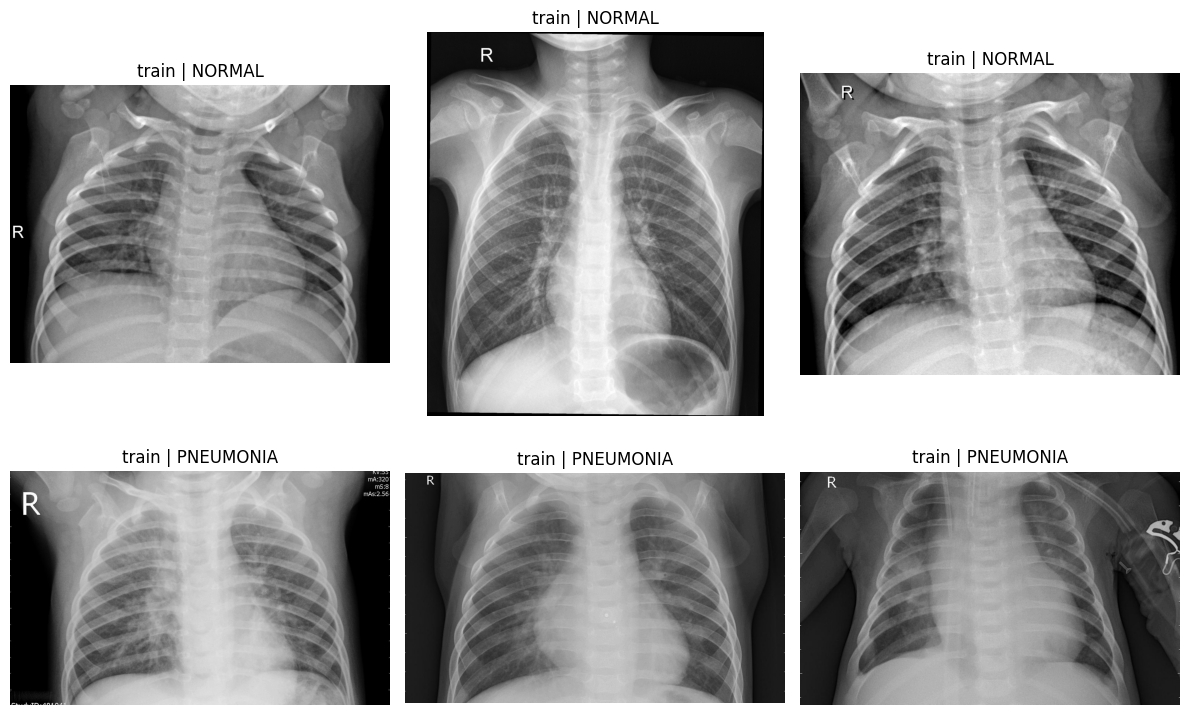

In [ ]:
def show_random_samples(dataset_dir: Path, split="train", n_per_class=3, save_path=None):
    fig, axes = plt.subplots(2, n_per_class, figsize=(4 * n_per_class, 8))
    classes = ["NORMAL", "PNEUMONIA"]

    for row, cls in enumerate(classes):
        img_paths = list_images_in_dir(dataset_dir / split / cls)
        chosen = random.sample(img_paths, min(n_per_class, len(img_paths)))

        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis("off")

            if col < len(chosen):
                img = Image.open(chosen[col]).convert("L")
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{split} | {cls}")

    plt.tight_layout()
    plt.show()

show_random_samples(DATASET_DIR, split="train", n_per_class=3, save_path=OUTPUT_DIR / "sample_images_swin.png")

## 5. Define data augmentation and data preprocessing

> Training set use light augmentation：
> - small angle random rotation
> - slight random translation
> - slight brightness adjustment
> - slight contrast adjustment

> The pre-trained weights of the Swin Transformer come from ImageNet, so copy the X-ray grayscale image as a 3-channel input and use ImageNet's mean/std for normalization.

In [ ]:
# ImageNet normalization, matching the pretrained Swin Transformer
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# training set uses lightweight data augmentation, and single-channel data is copied to three channels
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # copy one channel to a three channels format
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # resize to 224*224
    transforms.RandomRotation(degrees=8), # rotation, data augmentation
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # affine
    transforms.ColorJitter(brightness=0.10, contrast=0.10), # color adjust
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # normalized (ImageNet)
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # copy one channel to a three channels format
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # resize to 224*224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # normalized (ImageNet)
])

## 6. Building Dataset and DataLoader

In [ ]:
# construct dataset and dataloader
train_dataset = datasets.ImageFolder(DATASET_DIR / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_DIR / "val", transform=eval_transform)
test_dataset = datasets.ImageFolder(DATASET_DIR / "test", transform=eval_transform)

print("ImageFolder class_to_idx:", train_dataset.class_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

ImageFolder class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


## 7. Handle class imbalance and building a pre-trained Swin Transformer

> Use **class-weighted cross-entropy loss**  
> The Swin Transformer is imported directly from `torchvision.models` and loads the ImageNet pre-trained weights  
> The final classification head is replaced by 2-class output

In [ ]:
# get class weights function (used in later class-weighted cross-entropy loss)
def compute_class_weights(imagefolder_dataset):
    targets = np.array(imagefolder_dataset.targets)
    class_counts = np.bincount(targets)
    class_weights = len(targets) / (len(class_counts) * class_counts)
    return class_counts, class_weights.astype(np.float32)

train_class_counts, class_weights = compute_class_weights(train_dataset)

print("Train class counts:", train_class_counts)
print("Class weights:", class_weights)

# import the ImageNet pre-trained Swin Transformer, replace the last classification header
weights = Swin_T_Weights.IMAGENET1K_V1
model = swin_t(weights=weights)

# if only train the classification head, freeze the backbone
if FREEZE_BACKBONE:
    for param in model.parameters():
        param.requires_grad = False

# the last layer of torchvision's Swin-T is model.head
in_features = model.head.in_features
model.head = nn.Linear(in_features, 2) # replace (2 classes classification)

model = model.to(DEVICE)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) # class-weighted cross-entropy loss

# (only optimize parameters with requires_grad=True)
optimizer = torch.optim.AdamW( # AdamW optimizer
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.StepLR( # learning rate decay
    optimizer,
    step_size=LR_STEP_SIZE,
    gamma=LR_GAMMA
)

print(model.head)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Train class counts: [1140 3294]
Class weights: [1.9447368 0.6730419]
Linear(in_features=768, out_features=2, bias=True)
Trainable parameters: 27520892
Total parameters: 27520892


## 8. Define training and evaluation functions

In [ ]:
# train one epoch function
def run_one_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images) # forward pass
            loss = criterion(logits, labels) # compute loss

            if is_train:
                loss.backward() # backward pass
                optimizer.step() # update

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# predict function (use on later test set)
@torch.no_grad()
def predict_with_scores(model, loader, device=DEVICE):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1) # probability
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_logits.extend(logits.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_logits)
    )

## 9. Train the model and save the best model based on the accuracy on the validation set

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = -1.0
best_epoch = -1

start_time = time.time()

for epoch in range(NUM_EPOCHS): # train epoch times
    t0 = time.time()

    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer, DEVICE) # train on training set
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None, device=DEVICE) # evaluate on val set

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    dt = time.time() - t0

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | time={dt:.1f}s"
    )

    if val_acc > best_val_acc: # store the best model according to val acc
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())

    # learning rate decay
    scheduler.step()

training_time = time.time() - start_time
print(f"Training finished in {training_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

model.load_state_dict(best_model_wts) # load the best model weights

Epoch [01/12] | LR: 0.000060 | Train Loss: 0.1752 | Train Acc: 0.9244 | Val Loss: 0.1065 | Val Acc: 0.9712 | time=83.2s
Epoch [02/12] | LR: 0.000060 | Train Loss: 0.0860 | Train Acc: 0.9666 | Val Loss: 0.0787 | Val Acc: 0.9699 | time=83.0s
Epoch [03/12] | LR: 0.000060 | Train Loss: 0.0858 | Train Acc: 0.9691 | Val Loss: 0.0561 | Val Acc: 0.9799 | time=83.9s
Epoch [04/12] | LR: 0.000060 | Train Loss: 0.0531 | Train Acc: 0.9811 | Val Loss: 0.0410 | Val Acc: 0.9875 | time=83.0s
Epoch [05/12] | LR: 0.000030 | Train Loss: 0.0332 | Train Acc: 0.9865 | Val Loss: 0.0349 | Val Acc: 0.9887 | time=83.1s
Epoch [06/12] | LR: 0.000030 | Train Loss: 0.0289 | Train Acc: 0.9880 | Val Loss: 0.0494 | Val Acc: 0.9812 | time=83.5s
Epoch [07/12] | LR: 0.000030 | Train Loss: 0.0327 | Train Acc: 0.9887 | Val Loss: 0.0484 | Val Acc: 0.9850 | time=82.7s
Epoch [08/12] | LR: 0.000030 | Train Loss: 0.0364 | Train Acc: 0.9862 | Val Loss: 0.0323 | Val Acc: 0.9887 | time=82.5s
Epoch [09/12] | LR: 0.000015 | Train Los

<All keys matched successfully>

## 10. Plot training curves

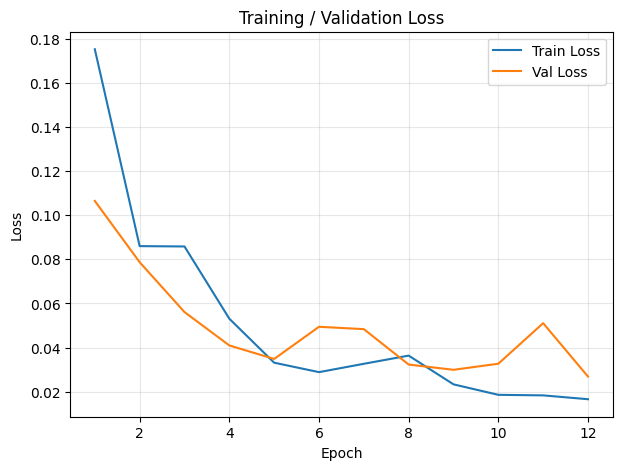

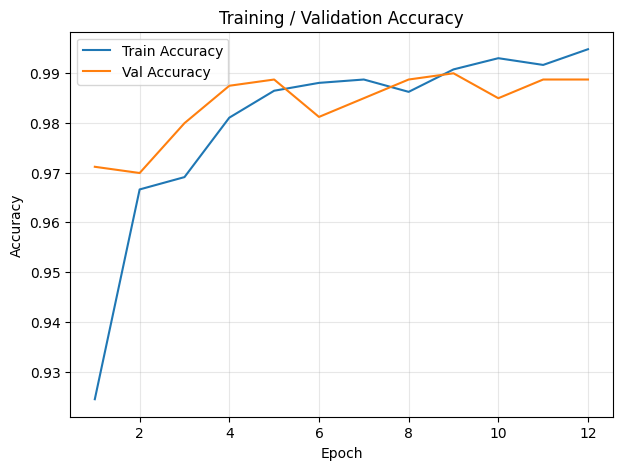

In [26]:
epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "swin_transformer_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "swin_transformer_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Evaluate the best model on the test set

> - Accuracy
> - Classification Report
> - Confusion Matrix
> - ROC-AUC
> - ROC Curve

In [ ]:
# test on test set
y_test, test_pred, test_probs, test_logits = predict_with_scores(model, test_loader, DEVICE)

# probability of the positive class (PNEUMONIA) is used as the input to the ROC-AUC
test_scores = test_probs[:, 1]

test_acc = accuracy_score(y_test, test_pred) #test acc
test_roc_auc = roc_auc_score(y_test, test_scores) #test auc

print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))

Test Accuracy: 0.9071
Test ROC-AUC: 0.9818


In [28]:
print("Classification Report: (Swin Transformer transfer learning)")
print(classification_report(
    y_test,
    test_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    digits=4
))

Classification Report: (Swin Transformer transfer learning)
              precision    recall  f1-score   support

      NORMAL     0.9889    0.7607    0.8599       234
   PNEUMONIA     0.8739    0.9949    0.9305       390

    accuracy                         0.9071       624
   macro avg     0.9314    0.8778    0.8952       624
weighted avg     0.9170    0.9071    0.9040       624



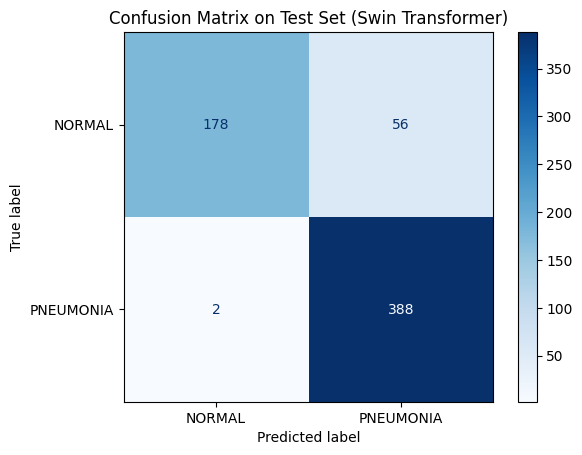

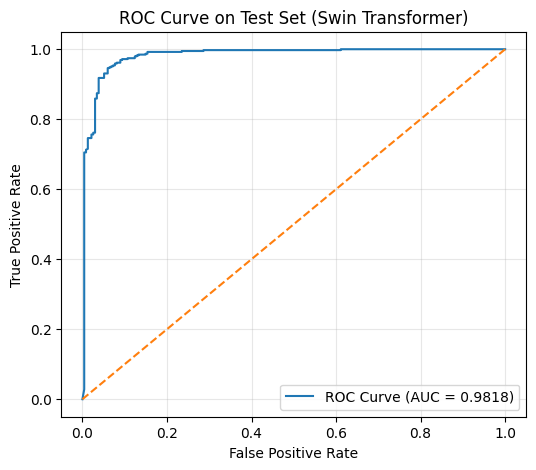

Confusion matrix saved to: /Users/wangzhichong/ML_HW/project/main/outputs/swin_transformer_confusion_matrix.png
ROC curve saved to: /Users/wangzhichong/ML_HW/project/main/outputs/swin_transformer_roc_curve.png


In [ ]:
# plot confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set (Swin Transformer)")
plt.savefig(OUTPUT_DIR / "swin_transformer_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (Swin Transformer)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "swin_transformer_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", (OUTPUT_DIR / "swin_transformer_confusion_matrix.png").resolve())
print("ROC curve saved to:", (OUTPUT_DIR / "swin_transformer_roc_curve.png").resolve())

## 12. Observe the samples with incorrect predictions

In [ ]:
# reconstruct a dataset without random augmentation and with return paths for visualization of incorrect predictions
class ChestXrayWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path = self.samples[index][0]
        return image, label, path

test_vis_dataset = ChestXrayWithPaths(DATASET_DIR / "test", transform=eval_transform)
test_vis_loader = DataLoader(
    test_vis_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

# collect misclassified samples function
@torch.no_grad()
def collect_misclassified_samples(model, loader, device=DEVICE):
    model.eval()
    results = []

    for images, labels, paths in loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        labels = labels.numpy()

        for i in range(len(paths)):
            if preds[i] != labels[i]:
                results.append((paths[i], labels[i], preds[i]))
    return results

misclassified = collect_misclassified_samples(model, test_vis_loader, DEVICE)
print("Number of misclassified samples:", len(misclassified))

Number of misclassified samples: 58


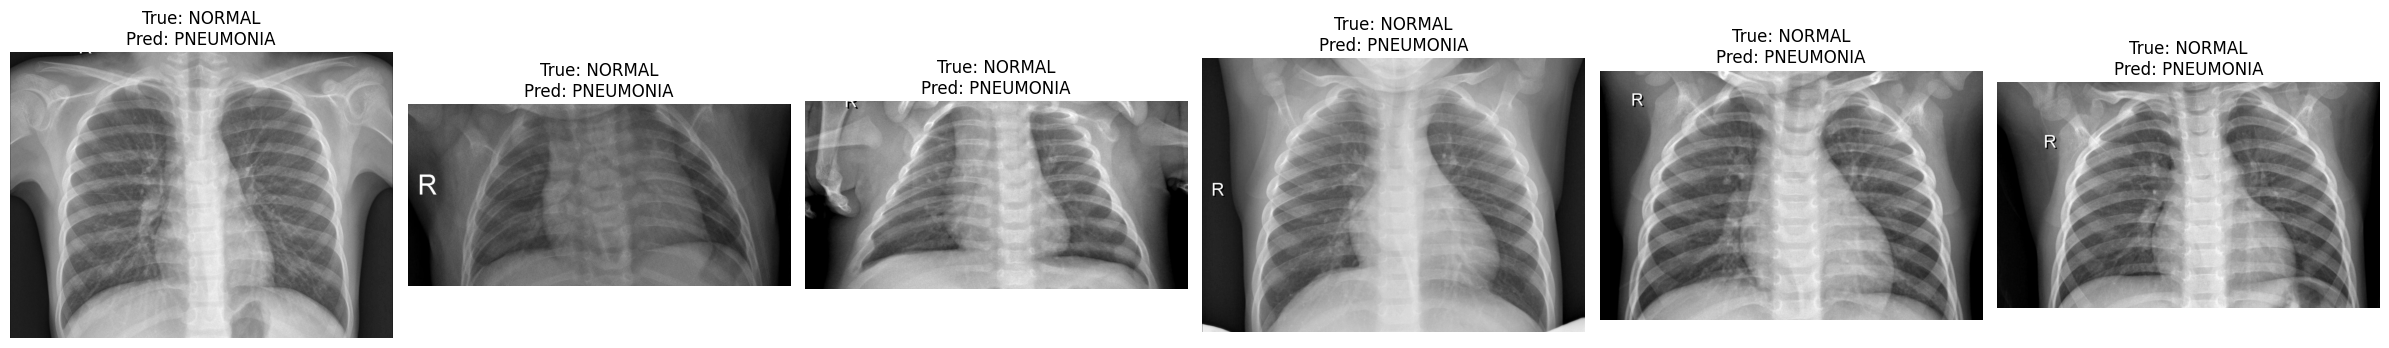

In [ ]:
# show misclassified samples function
def show_misclassified_samples(misclassified, n=6):
    if len(misclassified) == 0:
        print("No misclassified samples.")
        return

    chosen = misclassified[:min(n, len(misclassified))]
    fig, axes = plt.subplots(1, len(chosen), figsize=(4 * len(chosen), 4))
    if len(chosen) == 1:
        axes = [axes]

    for ax, (img_path, true_label, pred_label) in zip(axes, chosen):
        img = Image.open(img_path).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(f"True: {IDX_TO_CLASS[true_label]}\nPred: {IDX_TO_CLASS[pred_label]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_samples(misclassified, n=6)

## 13. Save the best model

> The model save to `models/`  
> Images results save to `outputs/`

In [32]:
model_path = MODEL_DIR / "swin_transformer_transfer_learning_best.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": CLASS_TO_IDX,
    "image_size": IMAGE_SIZE,
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_acc": test_acc,
    "test_roc_auc": test_roc_auc,
    "pretrained_weights": "Swin_T_Weights.IMAGENET1K_V1",
    "freeze_backbone": FREEZE_BACKBONE,
}, model_path)

print("Best model has been saved to:", model_path.resolve())

Best model has been saved to: /Users/wangzhichong/ML_HW/project/main/models/swin_transformer_transfer_learning_best.pth
